# Stock Portfolio Risk & Return Analysis

### Question: Given a set of stocks across different sectors, what is the historical risk-return profile of each and what portfolio allocation would have minimized risk for an expected return over the past 5 year period?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Matplotlib is building the font cache; this may take a moment.


In [2]:
sns.set_theme(style="whitegrid")

# Consistent palette across dashboard
PALETTE = sns.color_palette("husl", 9)
BENCHMARK_COLOR = "black"
CMAP = "RdBu_r"        # for correlation heatmap
CMAP_SCATTER = "viridis"  # for Sharpe-coloured scatters

os.makedirs("outputs/figures", exist_ok=True)

BENCHMARK = "SPY"

# Load data from notebooks
returns = pd.read_csv("daily_returns.csv", index_col=0, parse_dates=True)
cumulative = pd.read_csv("cumulative_returns.csv", index_col=0, parse_dates=True)
risk_return = pd.read_csv("risk_return_summary.csv", index_col=0)
corr = pd.read_csv("correlation_matrix.csv", index_col=0)
rolling_vol = pd.read_csv("rolling_volatility_30d.csv", index_col=0, parse_dates=True)
max_drawdown = pd.read_csv("max_drawdown.csv", index_col=0).iloc[:, 0]

# Monte Carlo simulation results
asset_returns = returns.drop(columns=[BENCHMARK])
tickers = asset_returns.columns.tolist()
n_assets = len(tickers)
ann_return = asset_returns.mean() * 252
cov_matrix = asset_returns.cov() * 252

np.random.seed(42)
n_portfolios = 10000
sim = np.zeros((3, n_portfolios))
weights_record = []
for i in range(n_portfolios):
    w = np.random.random(n_assets)
    w /= w.sum()
    weights_record.append(w)
    port_return = np.dot(w, ann_return)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    sim[0, i] = port_vol
    sim[1, i] = port_return
    sim[2, i] = port_return / port_vol

sim_results = pd.DataFrame(sim.T, columns=["volatility", "return", "sharpe"])
max_sharpe_idx = sim_results["sharpe"].idxmax()
min_vol_idx = sim_results["volatility"].idxmin()
max_sharpe_port = sim_results.loc[max_sharpe_idx]
min_vol_port = sim_results.loc[min_vol_idx]

# Consistent color mapping
color_map = {ticker: PALETTE[i] for i, ticker in enumerate(
    [t for t in cumulative.columns if t != BENCHMARK]
)}
color_map[BENCHMARK] = BENCHMARK_COLOR

## Dashboard:
#### Combined the six core visuals into a single dashboard with a consistent colour pallette for ease of readability. SPY has been stylized consistently everywhere so that it can be differentiated as the benchmark measure.

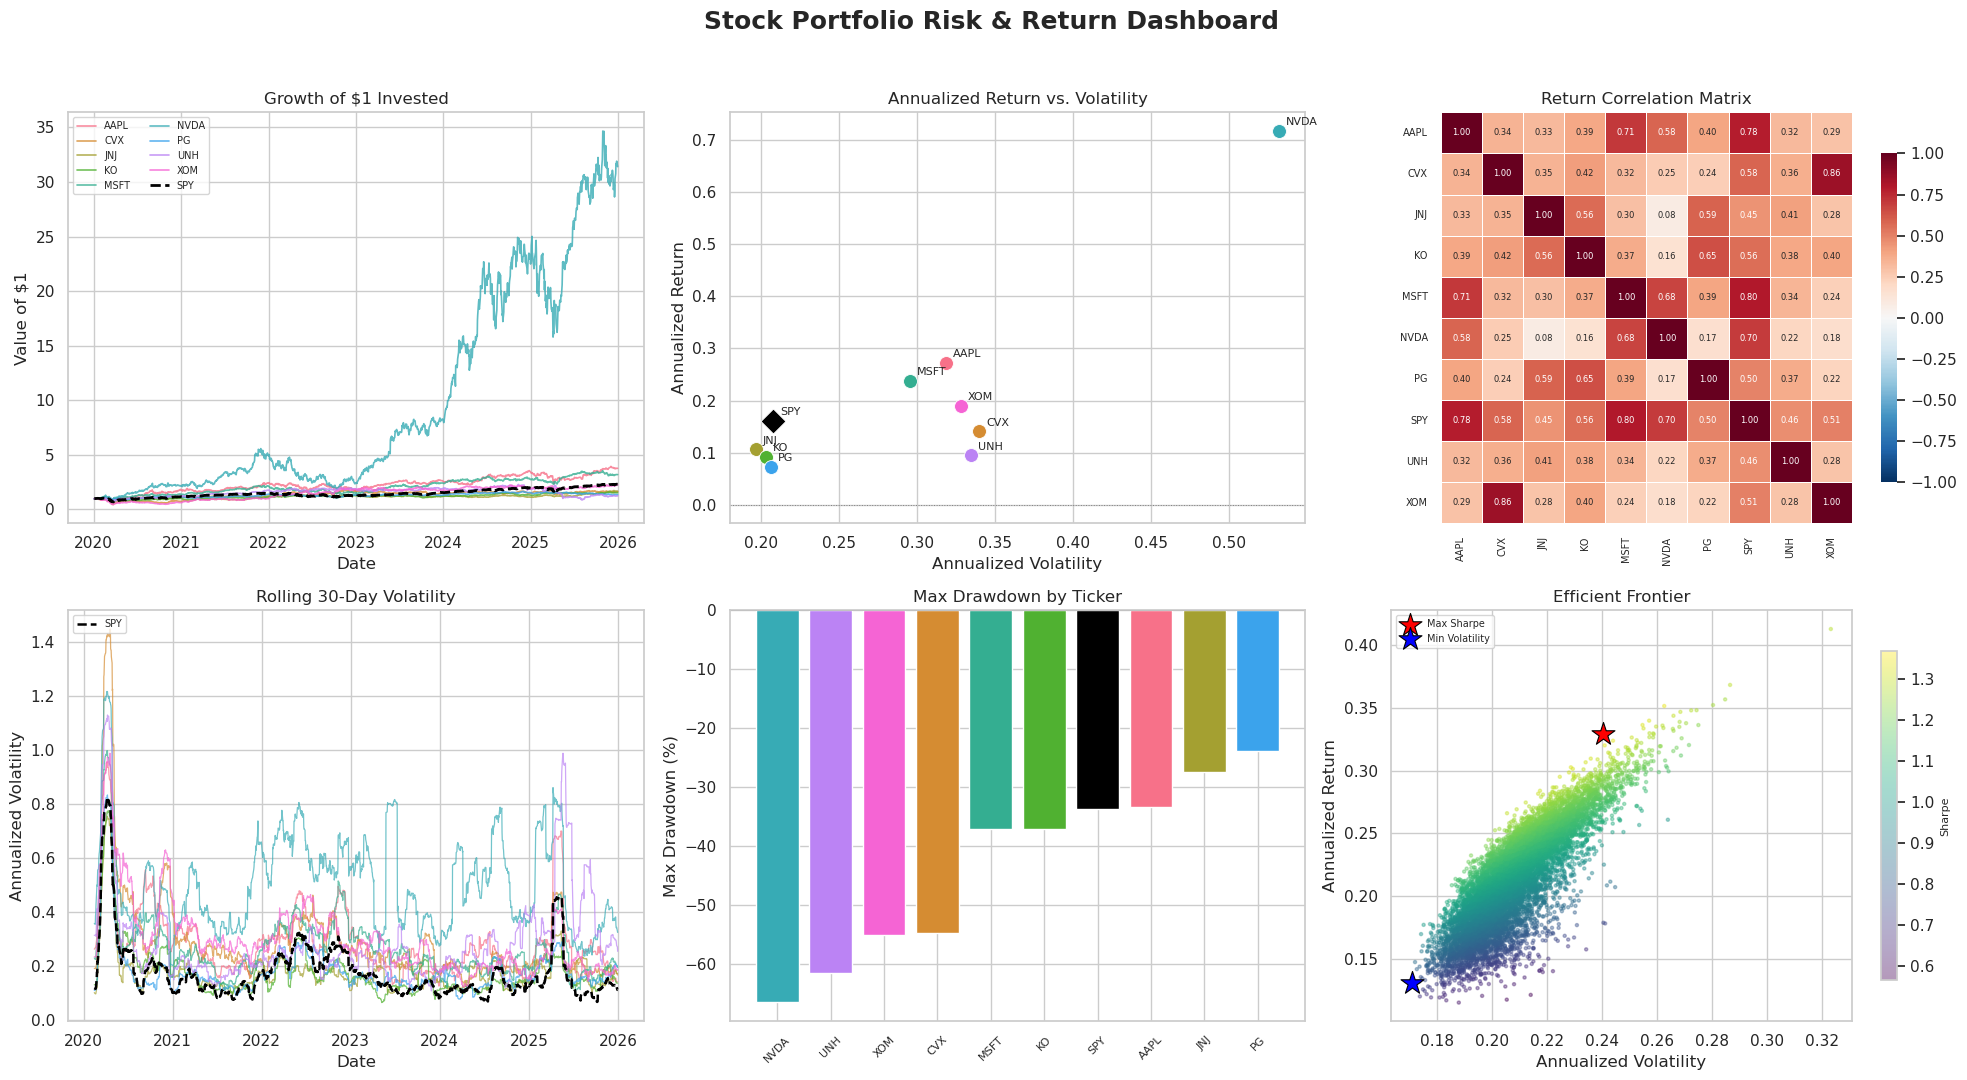

In [4]:
#Dashboard
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Stock Portfolio Risk & Return Dashboard", fontsize=18, fontweight="bold")

#Growth of $1
ax = axes[0, 0]
for ticker in cumulative.columns:
    if ticker == BENCHMARK:
        continue
    ax.plot(cumulative.index, cumulative[ticker], label=ticker,
            color=color_map[ticker], alpha=0.8, linewidth=1.2)
ax.plot(cumulative.index, cumulative[BENCHMARK], label=BENCHMARK,
        color=BENCHMARK_COLOR, linewidth=2, linestyle="--")
ax.set_title("Growth of $1 Invested")
ax.set_xlabel("Date")
ax.set_ylabel("Value of $1")
ax.legend(loc="upper left", fontsize=7, ncol=2)

#Risk vs. Return scatterplot
ax = axes[0, 1]
for ticker in risk_return.index:
    is_bm = ticker == BENCHMARK
    ax.scatter(risk_return.loc[ticker, "ann_vol"], risk_return.loc[ticker, "ann_return"],
               s=160 if is_bm else 100, color=color_map[ticker],
               marker="D" if is_bm else "o", edgecolor="white", linewidth=0.6, zorder=3)
    ax.annotate(ticker, (risk_return.loc[ticker, "ann_vol"], risk_return.loc[ticker, "ann_return"]),
                xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set_title("Annualized Return vs. Volatility")
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")

#Correlation heatmap
ax = axes[0, 2]
sns.heatmap(corr, annot=True, fmt=".2f", cmap=CMAP, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot_kws={"size": 6}, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Return Correlation Matrix")
ax.tick_params(labelsize=7)

#Rolling 30-day volatility
ax = axes[1, 0]
for ticker in rolling_vol.columns:
    if ticker == BENCHMARK:
        continue
    ax.plot(rolling_vol.index, rolling_vol[ticker], color=color_map[ticker],
            alpha=0.7, linewidth=0.9)
ax.plot(rolling_vol.index, rolling_vol[BENCHMARK], color=BENCHMARK_COLOR,
        linewidth=1.8, linestyle="--", label=BENCHMARK)
ax.set_title("Rolling 30-Day Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.legend(loc="upper left", fontsize=7)

#Max drawdown bar chart
ax = axes[1, 1]
sorted_dd = max_drawdown.sort_values()
bar_colors = [color_map[t] for t in sorted_dd.index]
ax.bar(sorted_dd.index, sorted_dd.values * 100, color=bar_colors)
ax.set_title("Max Drawdown by Ticker")
ax.set_ylabel("Max Drawdown (%)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.tick_params(axis="x", labelrotation=45, labelsize=8)

#Efficient frontier
ax = axes[1, 2]
sc = ax.scatter(sim_results["volatility"], sim_results["return"],
                 c=sim_results["sharpe"], cmap=CMAP_SCATTER, s=5, alpha=0.4)
ax.scatter(max_sharpe_port["volatility"], max_sharpe_port["return"],
           marker="*", color="red", s=300, edgecolor="black", linewidth=0.8,
           label="Max Sharpe", zorder=5)
ax.scatter(min_vol_port["volatility"], min_vol_port["return"],
           marker="*", color="blue", s=300, edgecolor="black", linewidth=0.8,
           label="Min Volatility", zorder=5)
ax.set_title("Efficient Frontier")
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.legend(loc="upper left", fontsize=7)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Sharpe", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dashboard.png", dpi=200, bbox_inches="tight")
plt.show()

### Dashboard saved as a single 2x3 image combining figures of growth of \$1, risk & return, return correlation, rolling volatility, max drawdown and efficient frontier into a cohesive visual summary.